In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [ ]:
iris = load_iris()
X = iris.data[:, 2:]   # petal length, petal width only
print("Shape:", X.shape)
print("First 5 rows:\n", X[:5])

Shape: (150, 2)
First 5 rows:
 [[1.4 0.2]
 [1.4 0.2]
 [1.3 0.2]
 [1.5 0.2]
 [1.4 0.2]]


In [ ]:
print("Before Scaling:")
print(f"Petal Length → mean: {X[:,0].mean():.2f}, std: {X[:,0].std():.2f}")
print(f"Petal Width  → mean: {X[:,1].mean():.2f}, std: {X[:,1].std():.2f}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nAfter Scaling:")
print(f"Petal Length → mean: {X_scaled[:,0].mean():.2f}, std: {X_scaled[:,0].std():.2f}")
print(f"Petal Width  → mean: {X_scaled[:,1].mean():.2f}, std: {X_scaled[:,1].std():.2f}")

Before Scaling:
Petal Length → mean: 3.76, std: 1.76
Petal Width  → mean: 1.20, std: 0.76

After Scaling:
Petal Length → mean: -0.00, std: 1.00
Petal Width  → mean: -0.00, std: 1.00


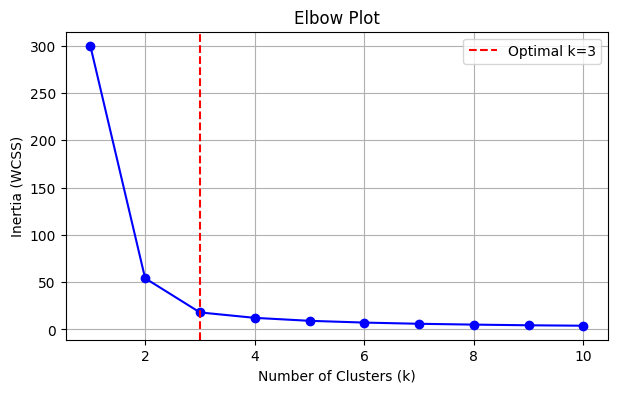

In [ ]:
inertia = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(list(k_range), inertia, 'o-', color='blue')
plt.axvline(x=3, color='red', linestyle='--', label='Optimal k=3')
plt.title("Elbow Plot")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (WCSS)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
km_final = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = km_final.fit_predict(X_scaled)
centers = scaler.inverse_transform(km_final.cluster_centers_)

print("Cluster labels:", labels)
print("Cluster centers (original scale):\n", centers)

Cluster labels: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 2 2
 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 0 0 0 0 0 2 0 0 0 0
 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0]
Cluster centers (original scale):
 [[5.56666667 2.05625   ]
 [1.462      0.246     ]
 [4.29615385 1.325     ]]


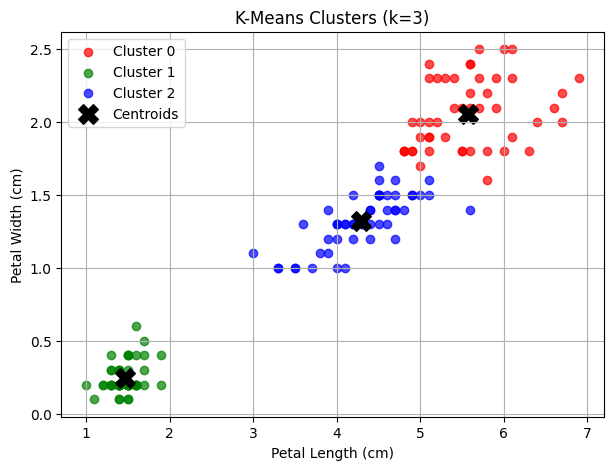

In [ ]:
colors = ['red', 'green', 'blue']

plt.figure(figsize=(7, 5))
for i in range(3):
    mask = labels == i
    plt.scatter(X[mask, 0], X[mask, 1], c=colors[i], label=f'Cluster {i}', alpha=0.7)

plt.scatter(centers[:, 0], centers[:, 1], c='black', marker='X', s=200, label='Centroids')
plt.title("K-Means Clusters (k=3)")
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.legend()
plt.grid(True)
plt.show()